# imports and install

In [1]:
pip install pyprojroot


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
from pyprojroot.here import here
import ast
from collections import Counter

# Cleaning

In [4]:

# Relative to the root of the GitHub repository
q_path = here("Data/demographic/questionnair.csv")

if not q_path.is_file():
    raise FileNotFoundError(f"Questionnaire file not found: {q_path}")

df = pd.read_csv(q_path)


# Replace missing values with the mode of each column
for column in ["Q1", "Q2", "Q4"]:
    column_mode = df[column].dropna().mode().iloc[0]
    df[column] = df[column].fillna(column_mode)

def safe_eval(x):
    if pd.isna(x):
        return None  # or [] depending on your preference
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return None  # fallback for bad strings
    

df["Q3"] = df["Q3"].apply(safe_eval)
all_values = df['Q3'].dropna().explode()
most_common = [x for x, _ in Counter(all_values).most_common(3)]  # top 3

def fill_q3(x):
    if x is None:
        return most_common
    if isinstance(x, float) and pd.isna(x):
        return most_common
    if isinstance(x, list) and len(x) == 0:
        return most_common
    return x
df['Q3'] = df['Q3'].apply(fill_q3)


df.head()

,Q1,Q2,Q3,Q4,anon_id
0,CS,2.0,"[3, 4]",1.0,S0041
1,CE,4.0,"[2, 3, 4, 5]",1.0,S0066
2,SE,2.0,"[3, 4]",1.0,S0057
3,SE,3.0,"[2, 4]",1.0,NaN
4,CE,4.0,"[2, 3]",1.0,S0008


In [6]:
df["Q1"].value_counts()
#### major

Q1
SE        34
CE        20
CS        17
others     1
Name: count, dtype: int64

In [7]:
# Q2. To what extent do you use Large Language Models (LLMs) for coding? (e.g., ChatGPT, Copilot).
# 1 Never
# 2 Rarely (a few times per semester)
# 3 Sometimes (monthly)
# 4 Often (weekly)
# 5 Very often (daily or almost daily)

df["Q2"].value_counts()

Q2
4.0    31
3.0    23
2.0    10
5.0     7
1.0     1
Name: count, dtype: int64

In [8]:
# Q4. To What extent are you confident in your python skill?
#  Not confident at all
#  Slightly confident
#  Moderately confident
#  Very confident
#  Extremely confident

df["Q4"].value_counts()


Q4
3.0    32
2.0    19
4.0    12
1.0     6
5.0     3
Name: count, dtype: int64

# major

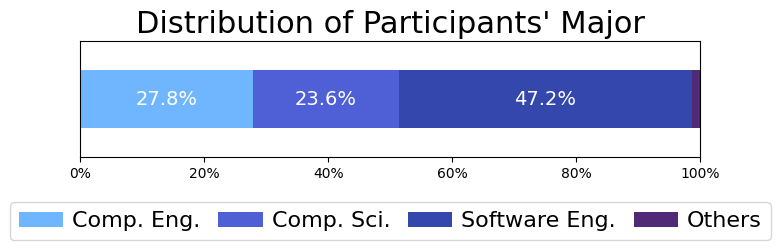

In [ ]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Create a "results" folder in the current working directory.
results_dir = Path.cwd() / "results"
results_dir.mkdir(parents=True, exist_ok=True)

# Output file path.
output_path = results_dir / "demo_major.pdf"

year_labels = {
    "CE": "Comp. Eng.",
    "CS": "Comp. Sci.",
    "SE": "Software Eng.", 
    "others": "Others"
}

# Compute percentages.
q1_percent = (
    df["Q1"]
    .astype(str)
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

# Convert to a single-row DataFrame for the stacked bar chart.
q1_df = pd.DataFrame([q1_percent])

colors = ["#6fb6ff", "#4f5fd5", "#3347ac", "#502977"]

ax = q1_df.plot(
    kind="barh",
    stacked=True,
    figsize=(8, 2),
    color=colors[:len(q1_percent)],
    legend=False
)

ax.set_title("Distribution of Participants' Major", fontsize=22)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_yticks([])
ax.set_xlim(0, 100)

# Format x-axis ticks as percentages.
ax.set_xticks(range(0, 101, 20))
ax.set_xticklabels([f"{x}%" for x in range(0, 101, 20)])

# Add percentage labels inside each segment.
left_position = 0

for value in q1_percent:
    if value > 5:
        ax.text(
            left_position + value / 2,
            0,
            f"{value:.1f}%",
            ha="center",
            va="center",
            color="white",
            fontsize=14
        )

    left_position += value

# Create custom legend labels.
custom_labels = [year_labels[key] for key in q1_percent.index]

ax.legend(
    handles=ax.patches[:len(custom_labels)],
    labels=custom_labels,
    title="",
    bbox_to_anchor=(0.5, -0.35),
    loc="upper center",
    ncol=len(custom_labels),
    fontsize=16,
    columnspacing=0.8,
    handletextpad=0.4,
    borderaxespad=0.2,
    labelspacing=0.3
)

plt.subplots_adjust(bottom=0.3)

# Save inside the current path/results folder.
plt.savefig(
    output_path,
    bbox_inches="tight",
    dpi=300
)

# print(f"Figure saved to: {output_path.resolve()}")

plt.show()

# LLM usage

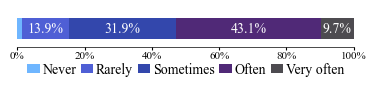

In [24]:

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ------------------------------------------------------------
# IEEE-compatible font and PDF settings
# ------------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Nimbus Roman"],
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "pdf.fonttype": 42,   # Avoid Type 3 fonts
    "ps.fonttype": 42,
})

# Create a results folder.
results_dir = Path.cwd() / "results"
results_dir.mkdir(parents=True, exist_ok=True)

output_path = results_dir / "demo_llm_use.pdf"

# Q2. To what extent do you use LLMs for coding?
llm_usage_labels = {
    1: "Never",
    2: "Rarely",
    3: "Sometimes",
    4: "Often",
    5: "Very often",
}

# Convert responses to numeric values.
q2_numeric = pd.to_numeric(df["Q2"], errors="coerce")

# Keep valid responses only.
q2_numeric = q2_numeric[q2_numeric.isin(llm_usage_labels)]

# Compute percentages in the intended response order.
q2_percent = (
    q2_numeric
    .value_counts(normalize=True)
    .reindex(llm_usage_labels.keys(), fill_value=0)
    .mul(100)
)

colors = [
    "#6fb6ff",
    "#4f5fd5",
    "#3347ac",
    "#502977",
    "#4D4B50",
]

# Generate at approximately the final IEEE column width.
fig, ax = plt.subplots(figsize=(3.45, 0.6))

left_position = 0.0

for value, color in zip(q2_percent, colors):
    ax.barh(
        y=0,
        width=value,
        left=left_position,
        height=0.42,
        color=color,
        edgecolor="none",
    )

    # Add labels only when the segment is wide enough.
    if value > 5:
        ax.text(
            left_position + value / 2,
            0,
            f"{value:.1f}%",
            ha="center",
            va="center",
            color="white",
            fontsize=10,
        )

    left_position += value

# Axis formatting.
ax.set_xlim(0, 100)
ax.set_ylim(-0.38, 0.38)
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")

ax.set_xticks(range(0, 101, 20))
ax.set_xticklabels([f"{x}%" for x in range(0, 101, 20)])
ax.tick_params(axis="x", length=2, pad=1)

# Remove unnecessary borders.
for spine in ["left", "right", "top"]:
    ax.spines[spine].set_visible(False)

ax.spines["bottom"].set_linewidth(0.5)

# Use explicit legend handles rather than bar patches.
legend_handles = [
    Patch(facecolor=color, edgecolor="none", label=label)
    for color, label in zip(colors, llm_usage_labels.values())
]

ax.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.27),
    ncol=5,
    frameon=False,
    fontsize=10,
    columnspacing=0.35,
    handlelength=0.9,
    handleheight=0.7,
    handletextpad=0.18,
    borderaxespad=0,
    labelspacing=0.1,
)

fig.subplots_adjust(
    left=0.02,
    right=0.995,
    top=0.96,
    bottom=0.34,
)

fig.savefig(
    output_path,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.01,
)

# print(f"Figure saved to: {output_path.resolve()}")

plt.show()


# python skill

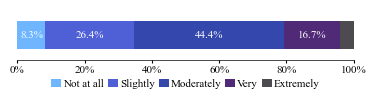

In [25]:

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ------------------------------------------------------------
# IEEE-compatible font and PDF settings
# ------------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Nimbus Roman"],
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "pdf.fonttype": 42,   # Avoid Type 3 fonts
    "ps.fonttype": 42,
})

# Create a results folder.
results_dir = Path.cwd() / "results"
results_dir.mkdir(parents=True, exist_ok=True)

output_path = results_dir / "demo_python.pdf"

# Q4. To what extent are you confident in your Python skills?
python_confidence_labels = {
    1: "Not at all",
    2: "Slightly",
    3: "Moderately",
    4: "Very",
    5: "Extremely",
}

# Convert responses to numeric values.
q4_numeric = pd.to_numeric(df["Q4"], errors="coerce")

# Keep valid responses only.
q4_numeric = q4_numeric[q4_numeric.isin(python_confidence_labels)]

# Compute percentages in the intended response order.
q4_percent = (
    q4_numeric
    .value_counts(normalize=True)
    .reindex(python_confidence_labels.keys(), fill_value=0)
    .mul(100)
)

colors = [
    "#6fb6ff",
    "#4f5fd5",
    "#3347ac",
    "#502977",
    "#4D4B50",
]

# Generate at approximately the final IEEE column width.
fig, ax = plt.subplots(figsize=(3.45, 0.82))

left_position = 0.0

for value, color in zip(q4_percent, colors):
    ax.barh(
        y=0,
        width=value,
        left=left_position,
        height=0.42,
        color=color,
        edgecolor="none",
    )

    # Add labels only when the segment is wide enough.
    if value > 5:
        ax.text(
            left_position + value / 2,
            0,
            f"{value:.1f}%",
            ha="center",
            va="center",
            color="white",
            fontsize=8,
        )

    left_position += value

# Axis formatting.
ax.set_xlim(0, 100)
ax.set_ylim(-0.38, 0.38)
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")

ax.set_xticks(range(0, 101, 20))
ax.set_xticklabels([f"{x}%" for x in range(0, 101, 20)])
ax.tick_params(axis="x", length=2, pad=1)

# Remove unnecessary borders.
for spine in ["left", "right", "top"]:
    ax.spines[spine].set_visible(False)

ax.spines["bottom"].set_linewidth(0.5)

# Use explicit handles for a reliable legend.
legend_handles = [
    Patch(facecolor=color, edgecolor="none", label=label)
    for color, label in zip(colors, python_confidence_labels.values())
]

ax.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.27),
    ncol=5,
    frameon=False,
    fontsize=8,
    columnspacing=0.35,
    handlelength=0.9,
    handleheight=0.7,
    handletextpad=0.18,
    borderaxespad=0,
    labelspacing=0.1,
)

fig.subplots_adjust(
    left=0.02,
    right=0.995,
    top=0.96,
    bottom=0.34,
)

fig.savefig(
    output_path,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.01,
)

# print(f"Figure saved to: {output_path.resolve()}")

plt.show()



# LLM interactions

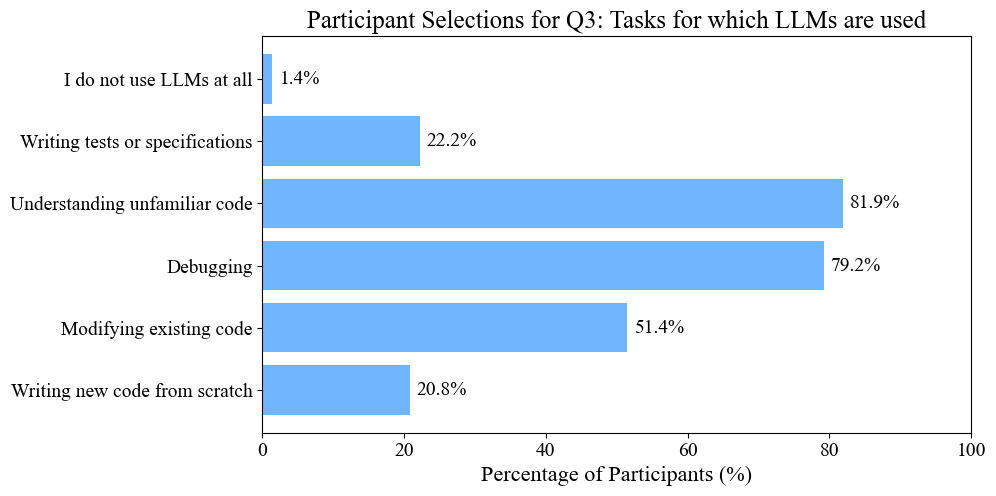

In [39]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Create a "results" folder in the current working directory.
results_dir = Path.cwd() / "results"
results_dir.mkdir(parents=True, exist_ok=True)

# Flatten the lists into a long series.
all_values = df["Q3"].dropna().explode()

# Count selections for each category.
selection_counts = all_values.value_counts().sort_index()

# Convert to percentage of participants.
percentages = selection_counts / len(df) * 100

# Map numeric codes to category labels.
category_labels = {
    1: "Writing new code from scratch",
    2: "Modifying existing code",
    3: "Debugging",
    4: "Understanding unfamiliar code",
    5: "Writing tests or specifications",
    6: "I do not use LLMs at all"
}

# Prepare data for plotting.
y_labels = [category_labels[k] for k in percentages.index]
x_values = percentages.values

# Plot horizontal bar chart.
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(y_labels, x_values, color="#6fb6ff")

ax.set_xlabel("Percentage of Participants (%)", fontsize=16)
ax.set_xlim(0, 100)
ax.set_title(
    "Participant Selections for Q3: Tasks for which LLMs are used",
    fontsize=18
)

ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)

# Add percentage labels at the end of each bar.
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center",
        fontsize=14
    )

plt.tight_layout()

# Save in the current path/results folder.
output_path = results_dir / "demo_llm_tasks.pdf"

plt.savefig(
    output_path,
    bbox_inches="tight",
    dpi=300
)

# print(f"Figure saved to: {output_path.resolve()}")

plt.show()

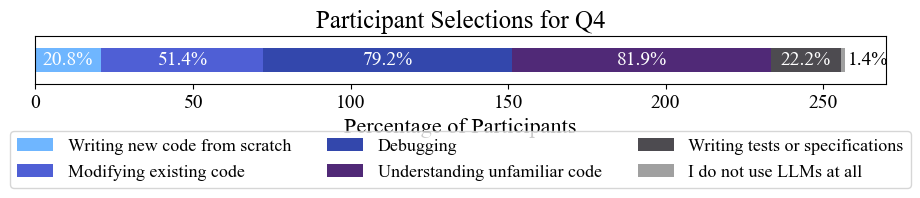

In [47]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Create a "results" folder in the current working directory.
results_dir = Path.cwd() / "results"
results_dir.mkdir(parents=True, exist_ok=True)

# Total participants.
total_participants = 72

# Count selections per category.
selection_counts = {}

for k in range(1, 7):
    selection_counts[k] = df["Q3"].apply(
        lambda x: k in x if isinstance(x, list) else False
    ).sum()

# Convert to percentages.
percentages = [
    value / total_participants * 100
    for value in selection_counts.values()
]

# Map numeric codes to category labels.
category_labels = {
    1: "Writing new code from scratch",
    2: "Modifying existing code",
    3: "Debugging",
    4: "Understanding unfamiliar code",
    5: "Writing tests or specifications",
    6: "I do not use LLMs at all"
}

labels = [category_labels[k] for k in range(1, 7)]

# Convert to DataFrame.
q4_df = pd.DataFrame([percentages], columns=labels)

# Colors.
colors = [
    "#6fb6ff",
    "#4f5fd5",
    "#3347ac",
    "#502977",
    "#4D4B50",
    "#a0a0a0"
]

# Plot.
fig, ax = plt.subplots(figsize=(10, 2.5))

ax = q4_df.plot(
    kind="barh",
    stacked=True,
    color=colors,
    legend=False,
    ax=ax
)

ax.set_title("Participant Selections for Q4", fontsize=18)
ax.set_xlabel("Percentage of Participants", fontsize=16)
ax.set_ylabel("")
ax.set_yticks([])
ax.tick_params(axis="x", labelsize=14)

# Dynamically set x-axis limit to sum plus padding.
ax.set_xlim(0, sum(percentages) * 1.05)

# Add percentage labels inside or outside segments.
for i, value in enumerate(percentages):
    xpos = sum(percentages[:i]) + value / 2

    if value >= 5:
        ax.text(
            xpos,
            0,
            f"{value:.1f}%",
            ha="center",
            va="center",
            color="white",
            fontsize=14
        )
    else:
        ax.text(
            sum(percentages[:i]) + value + 1,
            0,
            f"{value:.1f}%",
            ha="left",
            va="center",
            color="black",
            fontsize=14
        )

# Legend with two rows.
ax.legend(
    handles=ax.patches[:len(labels)],
    labels=labels,
    bbox_to_anchor=(0.5, -0.8),
    loc="upper center",
    ncol=3,
    fontsize=13
)

plt.subplots_adjust(bottom=0.45)
plt.tight_layout()

# Save in the current path/results folder.
output_path = results_dir / "demo_llm_tasks_stacked.pdf"

plt.savefig(
    output_path,
    bbox_inches="tight",
    dpi=300
)

# print(f"Figure saved to: {output_path.resolve()}")

plt.show()

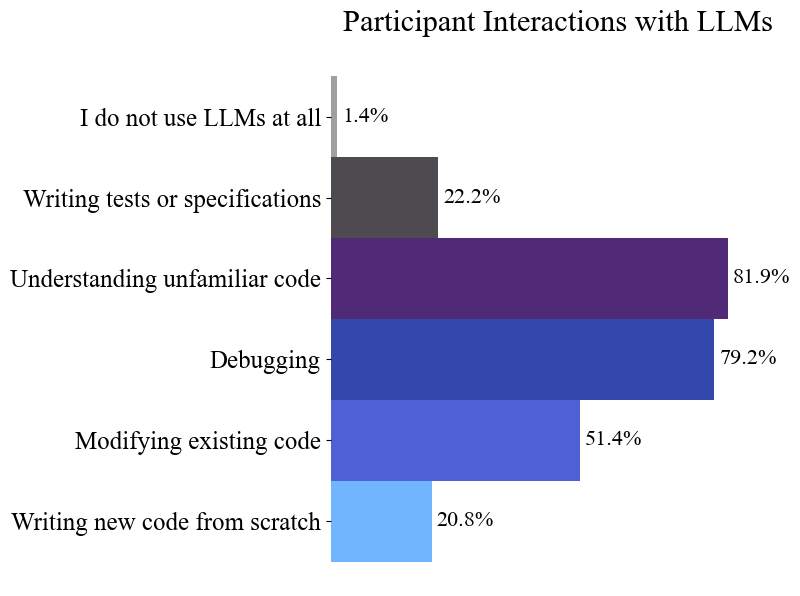

In [53]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Create the results folder in the current working directory.
results_dir = Path.cwd() / "results"
results_dir.mkdir(parents=True, exist_ok=True)

# Q3 contains the multi-select LLM interaction responses.
all_values = (
    df["Q3"]
    .dropna()
    .explode()
    .astype(int)
)

# Count selections and convert to percentages.
selection_counts = all_values.value_counts().sort_index()
percentages = selection_counts / len(df) * 100

# Map numeric codes to category labels.
category_labels = {
    1: "Writing new code from scratch",
    2: "Modifying existing code",
    3: "Debugging",
    4: "Understanding unfamiliar code",
    5: "Writing tests or specifications",
    6: "I do not use LLMs at all"
}

# Assign a color to each category.
colors = [
    "#6fb6ff",
    "#4f5fd5",
    "#3347ac",
    "#502977",
    "#4D4B50",
    "#a0a0a0"
]

# Prepare data for plotting.
y_labels = [category_labels[k] for k in percentages.index]
x_values = percentages.values
bar_colors = [colors[k - 1] for k in percentages.index]

# Plot horizontal bar chart.
fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.barh(
    y_labels,
    x_values,
    color=bar_colors,
    height=1.0
)

# Remove the x-axis.
ax.xaxis.set_visible(False)

# Remove all borders.
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(
    "Participant Interactions with LLMs",
    fontsize=22,
    pad=15
)

ax.tick_params(axis="y", labelsize=18)

# Leave room for labels outside the bars.
ax.set_xlim(0, max(x_values) + 12)

# Add percentage labels at the end of each bar.
for bar in bars:
    width = bar.get_width()

    ax.text(
        width + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center",
        fontsize=16
    )

plt.tight_layout()

output_path = results_dir / "demo_llm_goal.pdf"

plt.savefig(
    output_path,
    bbox_inches="tight",
    dpi=300
)

# print(f"Figure saved to: {output_path.resolve()}")

plt.show()